# M5 forecasting: top-down, bottom-up and middle-out

This notebook ports the three models of the [Pyro M5 starter kit](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit),
as already ported to [numpyro_forecast](https://juanitorduz.github.io/numpyro_forecast/docs/examples/m5_forecasting.html),
onto the PyMC forecasting classes. The competition panel is 30,490 daily unit-sales
series of Walmart items, a 28-day horizon, and 42,840 aggregates across 12 hierarchy
levels. The hierarchy, the covariates, the three models, and the scores are defined
below. [`load_m5`](../api/datasets.md) only reads the competition files.

The three models are three reconciliation strategies for the same hierarchy:

- **Top-down.** One Student-T regression on the log of total daily sales, with a
  trend, weekday effects, and day-of-month effects. The forecast is exponentiated
  and split to the items by their share of the last 28 training days, then
  Poisson-sampled.
- **Bottom-up.** A Gamma regression for every series. Mean and scale weights are
  shared by the items of a department in a store: three lagged log moving
  averages, a SNAP flag, and a weekday effect, passed through a bounded
  exponential. Forecasts are already at the bottom of the hierarchy.
- **Middle-out.** A Student-T regression on the store-by-department series, each
  divided by its lag-1 scale, with a trend, weekday effects, and 52 yearly
  Fourier harmonics. Forecasts are clipped at zero, restored to units, and split
  inside each store-department.

Priors and formulas follow the kit. Two deviations are deliberate:

- Inference is mean-field ADVI through `Forecaster`, not the kit's clipped,
  decaying, minibatch SVI. Posterior draws, and therefore scores, are not
  expected to match a NumPyro run.
- The fits use a hierarchy-preserving subset: the first item of every department,
  crossed with one store per state. The weight check still uses the full panel.
  CI sets `PYMC_FORECAST_SMOKE_TEST=1` and reruns this notebook on a synthetic
  two-store panel. That run does not download the competition files; its scores
  are a smoke check, not a forecast.


## Prepare notebook

Day 0 is 2011-01-29. The training file has 1,941 days; the evaluation file adds
the 28-day horizon. The bottom-up likelihood starts at day `T0 = 121`
(`37 + 28 * 3`), which is the kit's cut, not the first day a moving average is
numerically defined. Earlier days stay in that history and out of the likelihood.

`GAMMA_FLOOR` (`1e-3`) clamps a Gamma mean, a non-positive total before the log,
and an incomplete moving average. The bounded exponential caps at `1e3`, so an
early ADVI step cannot overflow. Poisson rates are clipped at `1e9`.


In [1]:
import logging
import os
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import scipy.sparse as sp
import xarray as xr

from pymc_forecast import Forecaster, ForecastingModel
from pymc_forecast.data import FUTURE_DIM, TIME_DIM
from pymc_forecast.datasets import M5Data, load_m5
from pymc_forecast.features import fourier_features
from pymc_forecast.metrics import crps_empirical
from pymc_forecast.model import FORECAST_VAR
from pymc_forecast.prediction import prediction_samples

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pytensor").setLevel(logging.ERROR)
plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110})

# Twelve levels, in competition order. A bottom series belongs to one group at each.
LEVELS = {
    "Level1": (),
    "Level2": ("state_id",),
    "Level3": ("store_id",),
    "Level4": ("cat_id",),
    "Level5": ("dept_id",),
    "Level6": ("state_id", "cat_id"),
    "Level7": ("state_id", "dept_id"),
    "Level8": ("store_id", "cat_id"),
    "Level9": ("store_id", "dept_id"),
    "Level10": ("item_id",),
    "Level11": ("state_id", "item_id"),
    "Level12": ("item_id", "store_id"),
}
# Median, plus both ends of the 50%, 67%, 95%, and 99% central intervals.
M5_INTERVALS = np.array([0.5, 0.67, 0.95, 0.99])
M5_QUANTILES = np.sort(
    np.concatenate([[0.5], (1.0 - M5_INTERVALS) / 2.0, (1.0 + M5_INTERVALS) / 2.0])
)

T0 = 121
HORIZON = 28
N_DAYS_TRAIN = 1941
N_DAYS = N_DAYS_TRAIN + HORIZON
SHARE_WINDOW = 28
GAMMA_FLOOR = 1e-3
RATE_CAP = 1e9
BEXP_BOUND = 1e3
MA_WINDOWS = (28, 56, 84)
MA_LAG = 28
BOTTOM_CHANNELS = ("dow", "snap", "saled", "ma28", "ma56", "ma84")
WEEKDAYS = ("Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun")
HEADS = ("mean", "scale")
LAGS = ("ma28", "ma56", "ma84")
SNAP_BY_STATE = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}

SMOKE = os.environ.get("PYMC_FORECAST_SMOKE_TEST", "0") == "1"
SEED = 2026
STORES = ["CA_1", "TX_1"] if SMOKE else ["CA_1", "TX_1", "WI_1"]
ORIGIN = (T0 + HORIZON) if SMOKE else N_DAYS_TRAIN
STEPS = (
    {"top-down": 40, "bottom-up": 40, "middle-out": 40}
    if SMOKE
    else {"top-down": 20_000, "bottom-up": 80_000, "middle-out": 20_000}
)
SAMPLES = 20 if SMOKE else 200
print(
    "Execution mode:",
    "CI smoke check; do not interpret fit quality" if SMOKE else "example panel",
)
print(f"stores={STORES}, origin={ORIGIN}, steps={STEPS}, samples={SAMPLES}")

Execution mode: example panel
stores=['CA_1', 'TX_1', 'WI_1'], origin=1941, steps={'top-down': 20000, 'bottom-up': 80000, 'middle-out': 20000}, samples=200


## The competition panel

`load_m5` downloads Nixtla's pinned mirror once and caches it. Series stay in
`sales_train_evaluation.csv` order. The 28 evaluation days are left-joined from
the test file, and weekly shelf prices are repeated across the days of
`wm_yr_wk`. A missing price is a missing listing, not a zero price: the weight
formula treats it as no dollar sales, and the bottom-up `saled` channel treats
it as a closed day.

The smoke path builds a tiny panel with the same identifier columns and one item
per department. It never touches the competition files.


In [2]:
def synthetic_m5(n_days, stores):
    """Tiny hierarchy-preserving panel for the CI smoke path. No download."""
    rng = np.random.default_rng(SEED)
    departments = (
        ("FOODS_1", "FOODS"),
        ("FOODS_2", "FOODS"),
        ("FOODS_3", "FOODS"),
        ("HOBBIES_1", "HOBBIES"),
        ("HOBBIES_2", "HOBBIES"),
        ("HOUSEHOLD_1", "HOUSEHOLD"),
        ("HOUSEHOLD_2", "HOUSEHOLD"),
    )
    rows = []
    for dept, cat in departments:
        item = f"{dept}_001"
        for store in stores:
            state = store.split("_", 1)[0]
            rows.append(
                {
                    "id": f"{item}_{store}",
                    "item_id": item,
                    "dept_id": dept,
                    "cat_id": cat,
                    "store_id": store,
                    "state_id": state,
                }
            )
    keys = pd.DataFrame(rows)
    sales = rng.poisson(2, size=(n_days, len(keys))).astype(np.float32)
    price = np.full((n_days, len(keys)), 1.5, dtype=np.float32)
    dates = pd.date_range("2011-01-29", periods=n_days, freq="D")
    day = np.arange(n_days)
    calendar = pd.DataFrame(
        {
            "date": dates,
            "snap_CA": (day % 14 < 7).astype(np.float64),
            "snap_TX": (day % 14 >= 7).astype(np.float64),
            "snap_WI": np.zeros(n_days, dtype=np.float64),
        }
    )
    return M5Data(sales, price, keys, calendar, pd.DataFrame())


if SMOKE:
    m5 = synthetic_m5(ORIGIN + HORIZON, STORES)
    print(f"synthetic smoke panel {m5.sales.shape}; competition files not loaded")
else:
    m5 = load_m5()
    print(
        f"sales {m5.sales.shape}, price {m5.price.shape}, "
        f"calendar {len(m5.calendar)}, weights {len(m5.weights)}"
    )
    assert m5.sales.shape == (N_DAYS, 30_490)
    assert m5.price.shape == m5.sales.shape
m5.keys.head(3)

sales (1969, 30490), price (1969, 30490), calendar 1969, weights 42840


,id,item_id,dept_id,cat_id,store_id,state_id
0,HOBBIES_1_001_CA_1,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA
1,HOBBIES_1_002_CA_1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA
2,HOBBIES_1_003_CA_1,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA


## Twelve levels

Each aggregate is a sum of bottom series. Level 1 is the total. Levels 2–5 are
state, store, category, and department. Levels 6–9 cross those. Levels 10–12 are
the item, the item in a state, and the item in a store — level 12 is the bottom
series itself.

A bottom series belongs to exactly one group at each level. The group id is the
rank of the sorted `Agg_Level_1/Agg_Level_2` label, which is also the key in
`weights_evaluation.csv` once the level name is prefixed. Sorting is part of the
contract: an unsorted id would still sum the right series, and then fail the
official-weight join.

The full panel is 30,490 series by 42,840 aggregates. A dense matrix would be
about 10 GB, and each series contributes exactly twelve ones, so the sum is a
CSR matrix with one row per bottom series and one column per aggregate.


In [3]:
class Aggregation:
    """Sparse sum from bottom series to the twelve levels.

    ``group_index[level]`` maps each bottom series to a column of that level,
    in sorted label order. ``labels`` are ``Level/Agg_Level_1/Agg_Level_2``.
    """

    def __init__(self, matrix, labels, slices, group_index):
        self.matrix = matrix
        self.labels = labels
        self.slices = slices
        self.group_index = group_index

    def labels_for(self, level):
        """``Agg_Level_1/Agg_Level_2`` labels of one level, sorted."""
        sl = self.slices[level]
        return [label.split("/", 1)[1] for label in self.labels[sl]]


def _pair_label(keys, columns):
    if not columns:
        return pd.Series(["Total/X"] * len(keys), index=keys.index)
    first = keys[columns[0]].astype(str)
    second = pd.Series("X", index=keys.index) if len(columns) == 1 else keys[columns[1]].astype(str)
    return first + "/" + second


def build_aggregation(keys):
    """Hierarchy of ``keys``. Group ids follow sorted label order."""
    missing = [
        column for columns in LEVELS.values() for column in columns if column not in keys.columns
    ]
    if missing:
        raise ValueError(f"keys are missing {sorted(set(missing))}")
    n_series = len(keys)
    rows, cols, labels = [], [], []
    slices, group_index = {}, {}
    offset = 0
    for level, columns in LEVELS.items():
        pairs = _pair_label(keys, columns)
        ordered = sorted(pairs.unique())
        index = {label: i for i, label in enumerate(ordered)}
        groups = pairs.map(index).to_numpy(dtype=np.int64)
        group_index[level] = groups
        rows.append(np.arange(n_series))
        cols.append(offset + groups)
        labels.extend(f"{level}/{label}" for label in ordered)
        slices[level] = slice(offset, offset + len(ordered))
        offset += len(ordered)
    matrix = sp.csr_matrix(
        (
            np.ones(n_series * len(LEVELS), dtype=np.float64),
            (np.concatenate(rows), np.concatenate(cols)),
        ),
        shape=(n_series, offset),
    )
    return Aggregation(matrix, labels, slices, group_index)


def aggregate(values, matrix):
    """Sum the last axis through a ``(n_series, n_aggregates)`` matrix."""
    values = np.asarray(values, dtype=np.float64)
    if values.shape[-1] != matrix.shape[0]:
        raise ValueError(
            f"last axis is {values.shape[-1]}, aggregation expects {matrix.shape[0]} series"
        )
    flat = values.reshape(-1, matrix.shape[0])
    summed = matrix.T.dot(flat.T).T
    return summed.reshape(*values.shape[:-1], matrix.shape[1])


def log_total(sales, *, floor=GAMMA_FLOOR):
    """Log of the panel total. Non-positive totals are floored first."""
    total = np.asarray(sales, dtype=np.float64).sum(-1)
    return np.log(np.maximum(total, floor))


def level_panel(sales, aggregation, level):
    """One level's columns, in the matrix's sorted-label order."""
    sl = aggregation.slices[level]
    return aggregate(sales, aggregation.matrix)[..., sl]

## Lag-1 scales and dollar-share weights

The scale of a column is the mean absolute lag-1 difference over its active
period. The active period starts at the first nonzero value. The jump from zero
into that day is excluded — it is an onset, not a day-to-day change — the
numerator is clamped at 1, and the denominator is the number of active days
minus one. An all-zero column uses the clamp, so a scale is never zero and never
divides the score by zero.

Weights are the dollar-sales share of each aggregate over the 28 days before
the forecast origin, normalized **inside its level**:

$$
w_{\ell,g}
= \frac{\sum_{t=t_1-28}^{t_1-1}\sum_{i \in g} y_{t,i}\,p_{t,i}}
       {\sum_{g' \in \ell}\sum_{t=t_1-28}^{t_1-1}\sum_{i \in g'} y_{t,i}\,p_{t,i}}.
$$

A missing price contributes nothing. A level whose dollar total is zero is split
uniformly. Recomputing these weights and joining on
`Level/Agg_Level_1/Agg_Level_2` is the check that this port still speaks the
competition's hierarchy. The smoke path has no official weight file, so it skips
the join.


In [4]:
def m5_scales(y):
    """Mean absolute lag-1 difference over each column's active period."""
    values = np.asarray(y, dtype=np.float64)
    if values.ndim != 2:
        raise ValueError(f"scales expect a 2-d array, got ndim {values.ndim}")
    duration, n_columns = values.shape
    if duration < 2:
        raise ValueError(f"scales need at least 2 days, got {duration}")
    # Days from the first nonzero through the end. An all-zero column is clamped
    # to 2 so the denominator below is 1 and the returned scale is the floor 1.
    active = np.maximum((np.cumsum(values, axis=0) != 0).sum(0), 2)
    start_value = values[duration - active, np.arange(n_columns)]
    # prepend=0 puts the onset jump into the sum; subtracting |start| removes it.
    lag1_norm = np.abs(np.diff(values, axis=0, prepend=0.0)).sum(0) - np.abs(start_value)
    return np.maximum(lag1_norm, 1.0) / (active - 1)


def m5_weights(sales, price, aggregation, t1, *, window=SHARE_WINDOW):
    """Dollar-sales share of every aggregate over the ``window`` days before ``t1``."""
    if t1 < window:
        raise ValueError(f"weights need {window} days before t1, got t1={t1}")
    sales = np.asarray(sales, dtype=np.float64)
    price = np.nan_to_num(np.asarray(price, dtype=np.float64), nan=0.0)
    dollars = (sales[t1 - window : t1] * price[t1 - window : t1]).sum(0)
    aggregated = aggregate(dollars, aggregation.matrix)
    weights = np.empty(aggregated.shape, dtype=np.float64)
    for sl in aggregation.slices.values():
        total = aggregated[sl].sum()
        width = sl.stop - sl.start
        weights[sl] = aggregated[sl] / total if total > 0.0 else np.full(width, 1.0 / width)
    return weights


def weight_gap(official, labels, ours):
    """Largest absolute gap against ``weights_evaluation.csv``, matched on label."""
    key = (
        official["Level_id"].astype(str)
        + "/"
        + official["Agg_Level_1"].astype(str)
        + "/"
        + official["Agg_Level_2"].astype(str)
    )
    table = official.assign(label=key, weight=official["weight"].astype(float))
    ours_frame = pd.DataFrame(
        {"label": list(labels), "weight_ours": np.asarray(ours, dtype=np.float64)}
    )
    joined = table.merge(ours_frame, on="label", how="inner")
    if len(joined) != len(labels):
        raise ValueError(f"{len(labels) - len(joined)} aggregates did not match official weights")
    return float((joined["weight"] - joined["weight_ours"]).abs().max())

In [5]:
if SMOKE:
    print("official-weight check skipped; smoke does not load the competition panel")
else:
    full = build_aggregation(m5.keys)
    levels = pd.DataFrame(
        [
            {
                "level": level,
                "grouping": " x ".join(columns) if columns else "total",
                "series": full.slices[level].stop - full.slices[level].start,
            }
            for level, columns in LEVELS.items()
        ]
    )
    print(f"aggregation matrix: {full.matrix.shape}")
    gap = weight_gap(
        m5.weights,
        full.labels,
        m5_weights(m5.sales, m5.price, full, N_DAYS_TRAIN),
    )
    print(f"{len(full.labels)} aggregates matched, largest official-weight gap {gap:.1e}")
    assert len(full.labels) == 42_840
    assert gap < 1e-4
    display(levels)

aggregation matrix: (30490, 42840)


42840 aggregates matched, largest official-weight gap 9.3e-10


,level,grouping,series
0,Level1,total,1
1,Level2,state_id,3
2,Level3,store_id,10
3,Level4,cat_id,3
4,Level5,dept_id,7
5,Level6,state_id x cat_id,9
6,Level7,state_id x dept_id,21
7,Level8,store_id x cat_id,30
8,Level9,store_id x dept_id,70
9,Level10,item_id,3049


## Covariates

Weekday is Monday = 0, taken from the calendar date. `years` is the row number
divided by 365, matching the kit rather than a 365.25 year. Christmas is
December 25. SNAP is the flag of the series' own state.

The top-down design is `years`, weekday, and 31 day-of-month dummies. The
middle-out design replaces the dummies with 52 yearly Fourier pairs at period
365.25 (`sin_1` … `cos_52`), from `fourier_features`. Both are built on the day
prefix that ends at the holdout and starts at day 0, so the trend and the
Fourier phase match the kit's calendar.

The bottom-up design has six channels, one value per series per day:

- `dow`, the shared weekday, broadcast to every series;
- `snap`, the state SNAP flag;
- `saled`, 1 when a price is listed and the day is not Christmas, else 0;
- `ma28`, `ma56`, `ma84`: the log of the mean sales over that window, ending
  28 days before the current day.

A moving average without a full window is `log(1e-3)`. The averages are
computed on sales **before** the later `T0` slice, so a likelihood that starts
at day 121 still sees the earlier history. The 28-day lag means the holdout
does not enter them: at forecast time the future averages are known.


In [6]:
def calendar_features(calendar):
    """Weekday, years-since-start, Christmas, day-of-month dummies, SNAP flags."""
    if "date" not in calendar.columns:
        raise ValueError("calendar is missing date")
    dates = pd.to_datetime(calendar["date"])
    out = pd.DataFrame(
        {
            "dow": dates.dt.dayofweek.to_numpy(dtype=np.int64),
            "years": np.arange(len(dates), dtype=np.float64) / 365.0,
            "christmas": ((dates.dt.month == 12) & (dates.dt.day == 25)).to_numpy(dtype=np.float64),
        }
    )
    for day in range(1, 32):
        out[f"dom_{day}"] = (dates.dt.day == day).to_numpy(dtype=np.float64)
    missing = [column for column in SNAP_BY_STATE.values() if column not in calendar.columns]
    if missing:
        raise ValueError(f"calendar is missing {missing}")
    for column in SNAP_BY_STATE.values():
        out[column] = calendar[column].to_numpy(dtype=np.float64)
    return out


def _time_index(calendar, n_days):
    if len(calendar) != n_days:
        raise ValueError(f"calendar has {len(calendar)} rows, expected {n_days}")
    dates = pd.to_datetime(calendar["date"])
    if dates.duplicated().any():
        raise ValueError("calendar dates are not unique")
    return dates.to_numpy()


def top_covariates(calendar):
    """Years, weekday, and 31 day-of-month dummies."""
    features = calendar_features(calendar)
    columns = ["years", "dow", *[f"dom_{day}" for day in range(1, 32)]]
    return xr.DataArray(
        features[columns].to_numpy(dtype=np.float64),
        dims=(TIME_DIM, "feature"),
        coords={TIME_DIM: _time_index(calendar, len(features)), "feature": columns},
        name="covariates",
    )


def middle_covariates(calendar):
    """Years, weekday, and 52 yearly Fourier pairs."""
    features = calendar_features(calendar)
    fourier = fourier_features(len(features), period=365.25, num_terms=52)
    names = ["years", "dow", *fourier.coords["fourier"].values.tolist()]
    values = np.column_stack(
        [features["years"].to_numpy(), features["dow"].to_numpy(), fourier.values]
    )
    return xr.DataArray(
        values,
        dims=(TIME_DIM, "feature"),
        coords={TIME_DIM: _time_index(calendar, len(features)), "feature": names},
        name="covariates",
    )


def lagged_log_moving_average(y, window, lag, *, floor=GAMMA_FLOOR):
    """Log mean over ``window`` days ending ``lag`` days before each day.

    Days without a full window are ``log(floor)``. The cumulative sum is float64.
    """
    values = np.asarray(y, dtype=np.float64)
    padded = np.concatenate([np.zeros((1, values.shape[1])), np.cumsum(values, axis=0)])
    t = np.arange(values.shape[0])
    stop = np.clip(t - lag + 1, 0, None)
    start = np.clip(stop - window, 0, None)
    mean = (padded[stop] - padded[start]) / window
    mean[t - lag + 1 - window < 0] = 0.0
    return np.log(np.maximum(mean, floor))


def bottom_covariates(sales, price, calendar, keys):
    """Weekday, SNAP, listed-and-open, and three lagged log moving averages."""
    sales = np.asarray(sales, dtype=np.float64)
    price = np.asarray(price, dtype=np.float64)
    features = calendar_features(calendar)
    christmas = features["christmas"].to_numpy()
    saled = (~np.isnan(price)).astype(np.float64) * (1.0 - christmas[:, None])
    state_index = np.array(
        [list(SNAP_BY_STATE).index(state) for state in keys["state_id"].astype(str)]
    )
    snap_table = features[list(SNAP_BY_STATE.values())].to_numpy(dtype=np.float64)
    channels = {
        "dow": np.broadcast_to(features["dow"].to_numpy()[:, None], sales.shape).copy(),
        "snap": snap_table[:, state_index],
        "saled": saled,
    }
    for window, name in zip(MA_WINDOWS, LAGS, strict=True):
        channels[name] = lagged_log_moving_average(sales, window, MA_LAG)
    values = np.stack([channels[name] for name in BOTTOM_CHANNELS], axis=-1)
    return xr.DataArray(
        values,
        dims=(TIME_DIM, "series", "channel"),
        coords={
            TIME_DIM: _time_index(calendar, sales.shape[0]),
            "series": keys["id"].astype(str).to_numpy(),
            "channel": list(BOTTOM_CHANNELS),
        },
        name="covariates",
    )


def select_series(keys, *, stores, items_per_dept):
    """First ``items_per_dept`` items of each department, crossed with ``stores``.

    Item identity is the first occurrence of ``item_id`` in sales-file order.
    The selected items are then crossed with the requested stores. Positional
    indices, so the caller can slice the sales array directly.
    """
    frame = keys.reset_index(drop=True)
    chosen = set()
    for _, group in frame.drop_duplicates("item_id").groupby("dept_id", sort=False):
        chosen.update(group["item_id"].astype(str).head(items_per_dept))
    mask = frame["store_id"].astype(str).isin(stores) & frame["item_id"].astype(str).isin(chosen)
    indices = np.flatnonzero(mask.to_numpy())
    if indices.size == 0:
        raise ValueError("selection is empty")
    return indices

## A panel the three models can share

The example keeps the first item of every department and crosses it with one
store per state, so every level of the hierarchy is present and the bottom-up
model still has a department effect inside each store. Covariates use the day
prefix that ends at the holdout.

The bottom-up likelihood is `panel_sales[T0:ORIGIN]`, with zeros clamped at
`1e-3`. Its covariates are sliced the same way, but the moving averages were
already computed on the unsliced prefix. Smoke mode holds out the 28 days after
`T0 + 28`, so that likelihood is not empty. The example holds out the
competition's evaluation window, days 1941:1969.

Middle-out does not model the bottom series. It models level 9, store by
department, each divided by its own scale on the training window.


In [7]:
chosen = select_series(m5.keys, stores=STORES, items_per_dept=1)
end = ORIGIN + HORIZON
panel_keys = m5.keys.iloc[chosen].reset_index(drop=True)
panel_sales = np.asarray(m5.sales[:end, chosen], dtype=np.float64)
panel_price = np.asarray(m5.price[:end, chosen], dtype=np.float64)
calendar = m5.calendar.iloc[:end].reset_index(drop=True)
panel = build_aggregation(panel_keys)
assert all(sl.stop > sl.start for sl in panel.slices.values())

store_ids = sorted(panel_keys["store_id"].astype(str).unique())
dept_ids = sorted(panel_keys["dept_id"].astype(str).unique())
store_index = (
    panel_keys["store_id"].astype(str).map(dict(zip(store_ids, range(len(store_ids)), strict=True)))
)
dept_index = (
    panel_keys["dept_id"].astype(str).map(dict(zip(dept_ids, range(len(dept_ids)), strict=True)))
)
store_index = store_index.to_numpy(dtype=np.int32)
dept_index = dept_index.to_numpy(dtype=np.int32)

cov_top = top_covariates(calendar)
cov_mid = middle_covariates(calendar)
cov_bottom = bottom_covariates(panel_sales, panel_price, calendar, panel_keys)


def observed(values, names, time):
    values = np.asarray(values, dtype=np.float64)
    if values.ndim == 1:
        values = values[:, None]
    return xr.DataArray(
        values,
        dims=(TIME_DIM, "series"),
        coords={TIME_DIM: np.asarray(time), "series": list(names)},
    )


time = cov_top[TIME_DIM].values
y_top = observed(log_total(panel_sales[:ORIGIN]), ["total"], time[:ORIGIN])
y_bottom = observed(
    np.maximum(panel_sales[T0:ORIGIN], GAMMA_FLOOR),
    panel_keys["id"],
    time[T0:ORIGIN],
)
assert y_bottom.sizes[TIME_DIM] == ORIGIN - T0
level9_labels = panel.labels_for("Level9")
level9 = level_panel(panel_sales, panel, "Level9")
scale_mid = m5_scales(level9[:ORIGIN])
y_mid = observed(level9[:ORIGIN] / scale_mid, level9_labels, time[:ORIGIN])
print(
    f"panel {panel_sales.shape} (days, series), "
    f"bottom-up likelihood days {T0}:{ORIGIN}, "
    f"level-9 series {len(level9_labels)}, departments {dept_ids}"
)

panel (1969, 21) (days, series), bottom-up likelihood days 121:1941, level-9 series 21, departments ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']


## Reconciliation and the competition scores

Top-down exponentiates the log-total forecast and treats every item as a member
of one group. Middle-out clips the level-9 forecast at zero, multiplies it back
by the training-window scale, and splits inside each store-department.
Bottom-up is already a bottom-level draw; it is not passed through this split.

The split is Poisson. The rate of a series is its group's draw times its share
of that group's sales over the last 28 training days. A group whose total is
zero is split uniformly. Non-finite rates are clipped to `[0, 1e9]`. Draws
follow the C-order ravel of the rate, in blocks only to bound the temporary, so
the seed fixes the Poisson noise and not the ADVI draws.

Scoring aggregates those bottom draws back up the same matrix. For each level,
weighted scaled CRPS is the horizon-mean empirical CRPS, times the level's
weight, divided by the level's scale, summed inside the level:

$$
\mathrm{WS\text{-}CRPS}_\ell
= \sum_{g \in \ell} w_g\,\frac{\overline{\mathrm{CRPS}}_g}{s_g}.
$$

WSPL is the pinball loss at the nine competition quantiles — the median and both
ends of the 50%, 67%, 95%, and 99% intervals,
$0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995$ —
mean over quantiles and the horizon, weighted and scaled the same way, then
averaged across the twelve levels. Lower is better. On this subset the numbers
are not competition scores.


In [8]:
def last_28_day_shares(train_sales, group_index, *, window=SHARE_WINDOW):
    """Share of each series in its group's sales over the last ``window`` days.

    A group whose total is zero is split uniformly across its members.
    """
    sales = np.asarray(train_sales, dtype=np.float64)
    groups = np.asarray(group_index, dtype=np.int64)
    totals = sales[-window:].sum(0)
    n_groups = int(groups.max()) + 1 if groups.size else 0
    group_totals = np.bincount(groups, weights=totals, minlength=n_groups)
    group_sizes = np.bincount(groups, minlength=n_groups)
    positive = group_totals[groups] > 0.0
    shares = np.empty(groups.shape, dtype=np.float64)
    shares[positive] = totals[positive] / group_totals[groups][positive]
    shares[~positive] = 1.0 / group_sizes[groups][~positive]
    return shares


def disaggregate(seed, group_draws, shares, group_index, *, chunk=50, rate_cap=RATE_CAP):
    """Poisson bottom draws with rate ``group draw * share``.

    The chunk only bounds the temporary. Draws follow the C-order ravel, so a
    different chunk does not change the seeded result.
    """
    draws = np.asarray(group_draws)
    share = np.asarray(shares, dtype=np.float64)
    groups = np.asarray(group_index, dtype=np.int64)
    rate = np.asarray(draws[..., groups], dtype=np.float64) * share
    rate = np.clip(np.nan_to_num(rate, nan=0.0, posinf=rate_cap, neginf=0.0), 0.0, rate_cap)
    flat = np.ascontiguousarray(rate).ravel()
    rng = np.random.default_rng(seed)
    out = np.empty(flat.shape, dtype=np.float32)
    trailing = int(np.prod(rate.shape[1:], dtype=int)) if rate.ndim > 1 else flat.size or 1
    block = max(int(chunk), 1) * trailing
    cursor = 0
    while cursor < flat.size:
        stop = min(cursor + block, flat.size)
        out[cursor:stop] = rng.poisson(flat[cursor:stop])
        cursor = stop
    return out.reshape(rate.shape)


def forecast_draws(result):
    """Stack chain and draw. Sample axis first, horizon second."""
    samples = prediction_samples(result)["forecast"]
    if "chain" in samples.dims and "draw" in samples.dims:
        samples = samples.stack(sample=("chain", "draw"))
    elif "draw" in samples.dims:
        samples = samples.rename(draw="sample")
    time_dim = FUTURE_DIM if FUTURE_DIM in samples.dims else TIME_DIM
    others = [dim for dim in samples.dims if dim not in ("sample", time_dim)]
    return samples.transpose("sample", time_dim, *others)


def reconcile_top_down(forecast, train_sales, *, seed):
    """Exponentiate a log-total forecast and split it by the last 28-day shares."""
    units = np.exp(np.asarray(forecast_draws(forecast).values, dtype=np.float64))
    if units.ndim == 2:
        units = units[..., None]
    groups = np.zeros(np.asarray(train_sales).shape[1], dtype=np.int64)
    return disaggregate(seed, units, last_28_day_shares(train_sales, groups), groups)


def reconcile_middle_out(forecast, train_sales, group_index, scale, *, seed):
    """Clip a scaled level-9 forecast at zero, restore units, and split within each group."""
    units = np.clip(np.asarray(forecast_draws(forecast).values, dtype=np.float64), 0.0, None)
    units = units * np.asarray(scale, dtype=np.float64)
    return disaggregate(seed, units, last_28_day_shares(train_sales, group_index), group_index)


def score_bottom(bottom_draws, truth, aggregation, weights, scales):
    """Per-level weighted scaled CRPS, plus WSPL, from bottom draws."""
    pred = aggregate(bottom_draws, aggregation.matrix)
    truth_levels = aggregate(truth, aggregation.matrix)
    weight = np.asarray(weights, dtype=np.float64)
    scale = np.asarray(scales, dtype=np.float64)
    scores = {}
    for level, sl in aggregation.slices.items():
        crps = crps_empirical(pred[..., sl], truth_levels[..., sl]).mean(axis=0)
        scores[level] = float(np.sum(weight[sl] * crps / scale[sl]))
    quantiles = np.quantile(pred, M5_QUANTILES, axis=0)
    error = quantiles - truth_levels[None]
    u = M5_QUANTILES[:, None, None]
    # Pinball: u*(y-q) when the quantile is below the truth, else (1-u)*(q-y).
    per_series = (np.where(error <= 0.0, -u, 1.0 - u) * error).mean(axis=(0, 1))
    level_scores = [
        np.sum(weight[sl] * per_series[sl] / scale[sl]) for sl in aggregation.slices.values()
    ]
    return scores, float(np.mean(level_scores))


def mean_level_score(scores):
    """Mean of the twelve level scores, in competition order."""
    return float(np.mean([scores[level] for level in LEVELS]))

## Fit

Each model is a `ForecastingModel`. One definition trains and forecasts:
`predict` registers the in-sample likelihood on `"obs"` and the horizon draw
on `"forecast"`. `Forecaster` fits the training slice with mean-field ADVI at
the default learning rate, then `forecast` replays the posterior and draws the
horizon from the prior, conditional on the covariates through the holdout. The
future weekday, SNAP flag, and lagged averages are known at forecast time.

On this subset the top-down and middle-out fits pass the package's ELBO check
at 20,000 steps. The bottom-up Gamma fit is still descending there; 80,000
steps clears the check. The seed fixes ADVI and the Poisson split. It does not
make these draws comparable to a NumPyro run.


In [9]:
def fit_and_forecast(model, data, covariates, steps):
    train_cov = covariates.sel({TIME_DIM: data[TIME_DIM].values})
    started = perf_counter()
    forecaster = Forecaster(
        model,
        data,
        train_cov,
        num_steps=steps,
        random_seed=SEED,
        progressbar=False,
    )
    elapsed = perf_counter() - started
    predicted = forecaster.forecast(
        covariates,
        num_samples=SAMPLES,
        random_seed=SEED,
        progressbar=False,
    )
    return forecaster, predicted, elapsed


def score(draws):
    draws = np.asarray(draws, dtype=np.float64)
    assert draws.shape[1:] == (HORIZON, panel_sales.shape[1])
    assert np.isfinite(draws).all()
    weights = m5_weights(panel_sales, panel_price, panel, ORIGIN)
    scales = m5_scales(aggregate(panel_sales[:ORIGIN], panel.matrix))
    truth = panel_sales[ORIGIN:end]
    scores, wspl = score_bottom(draws, truth, panel, weights, scales)
    assert list(scores) == list(LEVELS)
    assert np.isfinite(list(scores.values())).all()
    assert np.isfinite(wspl)
    return scores, wspl


def plot_loss(losses, title):
    fig, ax = plt.subplots()
    ax.plot(np.asarray(losses), color="C0", lw=1)
    ax.set_yscale("symlog")
    ax.set(title=title, xlabel="ADVI step", ylabel="ELBO loss")
    fig.tight_layout()
    plt.show()


results = {}

### Top-down

One regression on the log of total daily sales. The Student-T location is

$$
\mu_t = b + \tau\,\mathrm{years}_t + s_{\mathrm{dow}(t)}
+ \sum_{d=1}^{31} w_d\,\mathbf{1}[\mathrm{dom}(t) = d].
$$

$b \sim \mathrm{Normal}(0, 10)$, $\tau \sim \mathrm{LogNormal}(-2, 1)$,
each day-of-month weight is $\mathrm{Normal}(0, 1)$, the weekday effect is
$\mathrm{Normal}(0, 5)$, the degrees of freedom are $\mathrm{Uniform}(1, 10)$,
and the noise scale is $\mathrm{LogNormal}(-2, 1)$. `predict` adds that noise
in-sample and draws the same noise on the horizon. The reconciliation above
then exponentiates and applies the Poisson split.


In [10]:
class TopDownModel(ForecastingModel):
    """Trend, weekday, and day-of-month effects on the log total."""

    def model(self, covariates, data=None):
        years = np.asarray(covariates.sel(feature="years").values)
        dow = np.asarray(covariates.sel(feature="dow").values).astype(np.int32)
        dom_names = [
            str(name)
            for name in covariates.coords["feature"].values
            if str(name).startswith("dom_")
        ]
        dom = np.asarray(covariates.sel(feature=dom_names).values, dtype=np.float64)
        model = pm.modelcontext(None)
        model.add_coord("day_of_week", list(WEEKDAYS))
        model.add_coord("dom", dom_names)
        bias = pm.Normal("bias", 0.0, 10.0)
        trend = pm.LogNormal("trend", -2.0, 1.0)
        weight = pm.Normal("weight", 0.0, 1.0, dims="dom")
        seasonal = pm.Normal("seasonal", 0.0, 5.0, dims="day_of_week")
        prediction = bias + trend * years + seasonal[dow] + pt.dot(dom, weight)
        dof = pm.Uniform("dof", 1.0, 10.0)
        noise_scale = pm.LogNormal("noise_scale", -2.0, 1.0)
        # The extra axis is the single "total" series coord on y_top.
        self.predict(
            pm.StudentT.dist(nu=dof, mu=0.0, sigma=noise_scale),
            prediction[:, None],
        )

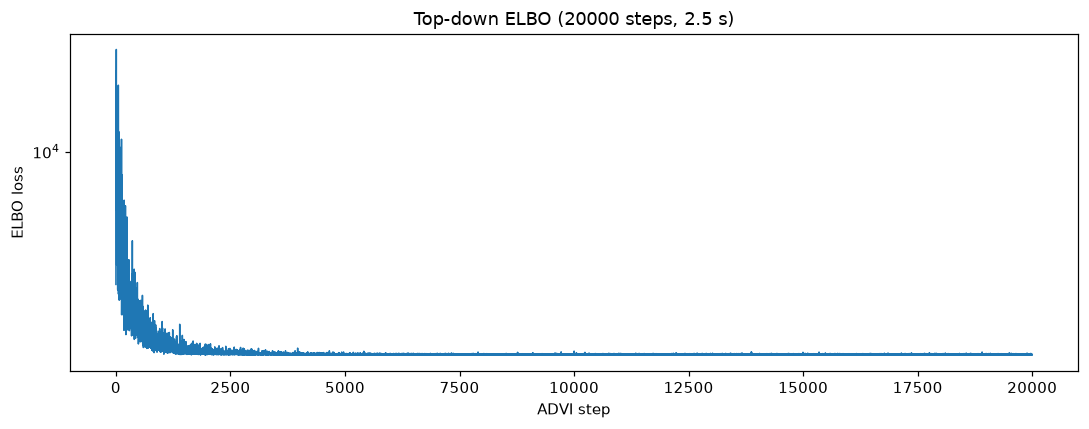

top-down WS-CRPS 0.881, WSPL 0.293


In [11]:
top, top_forecast, top_seconds = fit_and_forecast(TopDownModel(), y_top, cov_top, STEPS["top-down"])
plot_loss(top.losses, f"Top-down ELBO ({STEPS['top-down']} steps, {top_seconds:.1f} s)")
top_draws = reconcile_top_down(top_forecast, panel_sales[:ORIGIN], seed=SEED)
results["top-down"] = (*score(top_draws), top_seconds, top_draws)
print(
    f"top-down WS-CRPS {mean_level_score(results['top-down'][0]):.3f}, "
    f"WSPL {results['top-down'][1]:.3f}"
)

### Bottom-up

Each series borrows its department's weights inside its store. Two heads, mean
and scale, see the same three channels. A bounded exponential keeps an early
ADVI step finite,

$$
\mathrm{bexp}(x) = \mathrm{sigmoid}(x - \log 1000) \cdot 1000,
$$

and a closed day (`saled` = 0) collapses both heads to the floor $10^{-3}$:

$$
\begin{aligned}
\eta_{t,i,h}
&= \sum_{\ell \in \{28,56,84\}} \alpha_{s,h,\ell,d}\,\log\mathrm{MA}_{\ell,t,i}
+ \beta_{s,h,d}\,\mathrm{SNAP}_{t,i}
+ \gamma_{s,\mathrm{dow}(t),h,d}, \\
m_{t,i} &= \mathrm{bexp}(\eta_{t,i,\mathrm{mean}})\,\mathrm{saled}_{t,i} + 10^{-3}, \\
\sigma_{t,i} &= \mathrm{bexp}(\eta_{t,i,\mathrm{scale}})\,\mathrm{saled}_{t,i} + 10^{-3}.
\end{aligned}
$$

The observation is $\mathrm{Gamma}(\alpha = m/\sigma,\ \beta = 1/\sigma)$,
the shape-rate parameterization whose mean is $m$ and whose scale is $\sigma$.
Zeros in the data were clamped at $10^{-3}$ before they entered `y_bottom`.
`predict` is given a four-argument factory so the training Gamma uses the
in-sample scale segment and the forecast Gamma uses the future segment. Only
the mean head is the forecast; the scale head stays in the model as the Gamma
dispersion.


In [12]:
def _bounded_exp(x, bound=BEXP_BOUND):
    """Exponential capped at ``bound``. The cap is the ADVI overflow guard."""
    return pt.sigmoid(x - float(np.log(bound))) * bound


class BottomUpModel(ForecastingModel):
    """Department-level mean and scale for every store. Gamma observations."""

    def __init__(self, store_index, dept_index, store_ids, dept_ids):
        self.store_index = np.asarray(store_index, dtype=np.int32)
        self.dept_index = np.asarray(dept_index, dtype=np.int32)
        self.store_ids = tuple(store_ids)
        self.dept_ids = tuple(dept_ids)

    def model(self, covariates, data=None):
        model = pm.modelcontext(None)
        model.add_coord("store", list(self.store_ids))
        model.add_coord("dept", list(self.dept_ids))
        model.add_coord("head", list(HEADS))
        model.add_coord("lag", list(LAGS))
        model.add_coord("day_of_week", list(WEEKDAYS))
        ma_weight = pm.Normal("ma_weight", 0.0, 1.0, dims=("store", "head", "lag", "dept"))
        snap_weight = pm.Normal("snap_weight", 0.0, 1.0, dims=("store", "head", "dept"))
        seasonal = pm.Normal("seasonal", 0.0, 1.0, dims=("store", "day_of_week", "head", "dept"))
        # Weekday is shared, so the first series' channel is the calendar.
        dow = np.asarray(covariates.sel(channel="dow").values)[:, 0].astype(np.int32)
        snap = np.asarray(covariates.sel(channel="snap").values)
        saled = np.asarray(covariates.sel(channel="saled").values)
        log_ma = np.stack(
            [np.asarray(covariates.sel(channel=name).values) for name in LAGS],
            axis=-1,
        )
        store, dept = self.store_index, self.dept_index
        # ma_weight[store, head, lag, dept] -> (series, head, lag), times
        # log_ma (time, series, lag). Sum over the lag axis.
        moving = (ma_weight[store, :, :, dept][None] * log_ma[:, :, None, :]).sum(-1)
        snap_effect = snap_weight[store, :, dept][None] * snap[:, :, None]
        # (series, weekday, head) indexed by this day's weekday is
        # (series, time, head). Time has to lead.
        seasonal_effect = seasonal[store, :, :, dept][:, dow, :].transpose(1, 0, 2)
        combined = moving + snap_effect + seasonal_effect
        mean = _bounded_exp(combined[..., 0]) * saled + GAMMA_FLOOR
        scale = _bounded_exp(combined[..., 1]) * saled + GAMMA_FLOOR
        t_obs = self.horizon.t_obs

        def gamma(name, latent, dims, observed):
            scale_seg = scale[t_obs:] if name == FORECAST_VAR else scale[:t_obs]
            return pm.Gamma(
                name,
                alpha=latent / scale_seg,
                beta=1.0 / scale_seg,
                dims=dims,
                observed=observed,
            )

        self.predict(gamma, mean)

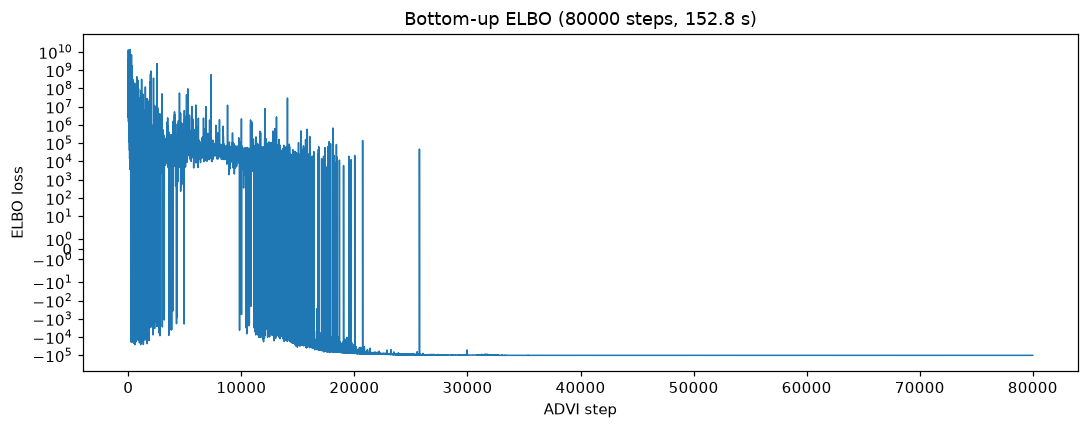

bottom-up WS-CRPS 0.975, WSPL 0.322


In [13]:
bottom_model = BottomUpModel(store_index, dept_index, store_ids, dept_ids)
bottom, bottom_forecast, bottom_seconds = fit_and_forecast(
    bottom_model,
    y_bottom,
    cov_bottom.isel({TIME_DIM: slice(T0, None)}),
    STEPS["bottom-up"],
)
plot_loss(bottom.losses, f"Bottom-up ELBO ({STEPS['bottom-up']} steps, {bottom_seconds:.1f} s)")
bottom_draws = np.asarray(forecast_draws(bottom_forecast).values)
results["bottom-up"] = (*score(bottom_draws), bottom_seconds, bottom_draws)
print(
    f"bottom-up WS-CRPS {mean_level_score(results['bottom-up'][0]):.3f}, "
    f"WSPL {results['bottom-up'][1]:.3f}"
)

### Middle-out

Level 9 is store by department. Each of those series was divided by its own
training-window scale before it became `y_mid`. Each series then has its own
regression and its own noise scale. The degrees of freedom are shared:

$$
\mu_{t,g} = b_g + \tau_g\,\mathrm{years}_t + s_{\mathrm{dow}(t),g}
+ \sum_{k=1}^{52} w_{g,k}\,f_{t,k}.
$$

$b_g \sim \mathrm{Normal}(0, 10)$, $\tau_g \sim \mathrm{LogNormal}(-1, 1)$,
the Fourier weights are $\mathrm{Normal}(0, 1)$, the weekday effect is
$\mathrm{Normal}(0, 1)$, the noise scale is $\mathrm{LogNormal}(-1, 1)$, and
$\nu \sim \mathrm{Uniform}(1, 10)$. The forecast is clipped at zero, multiplied
back by the training scale, and split to the items of the group.


In [14]:
class MiddleOutModel(ForecastingModel):
    """One scaled regression per series. Shared Student-T degrees of freedom."""

    def model(self, covariates, data=None):
        years = np.asarray(covariates.sel(feature="years").values)[:, None]
        dow = np.asarray(covariates.sel(feature="dow").values).astype(np.int32)
        fourier_names = [
            str(name)
            for name in covariates.coords["feature"].values
            if str(name).startswith(("sin_", "cos_"))
        ]
        feature = np.asarray(covariates.sel(feature=fourier_names).values, dtype=np.float64)
        model = pm.modelcontext(None)
        model.add_coord("day_of_week", list(WEEKDAYS))
        model.add_coord("fourier", fourier_names)
        bias = pm.Normal("bias", 0.0, 10.0, dims="series")
        trend = pm.LogNormal("trend", -1.0, 1.0, dims="series")
        weight = pm.Normal("weight", 0.0, 1.0, dims=("series", "fourier"))
        seasonal = pm.Normal("seasonal", 0.0, 1.0, dims=("day_of_week", "series"))
        noise_scale = pm.LogNormal("noise_scale", -1.0, 1.0, dims="series")
        dof = pm.Uniform("dof", 1.0, 10.0)
        prediction = bias + trend * years + seasonal[dow] + pt.dot(feature, weight.T)
        self.predict(pm.StudentT.dist(nu=dof, mu=0.0, sigma=noise_scale), prediction)

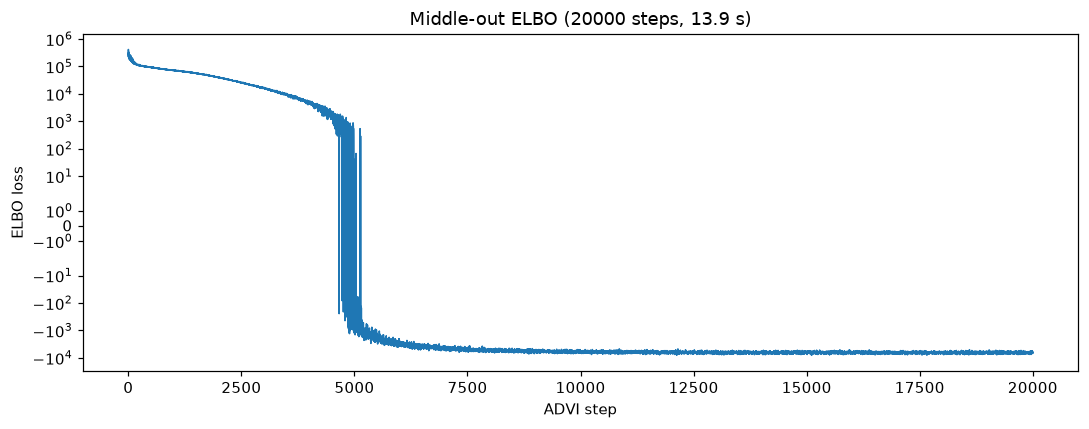

middle-out WS-CRPS 1.674, WSPL 0.673


In [15]:
middle, middle_forecast, middle_seconds = fit_and_forecast(
    MiddleOutModel(), y_mid, cov_mid, STEPS["middle-out"]
)
plot_loss(
    middle.losses,
    f"Middle-out ELBO ({STEPS['middle-out']} steps, {middle_seconds:.1f} s)",
)
middle_draws = reconcile_middle_out(
    middle_forecast,
    panel_sales[:ORIGIN],
    panel.group_index["Level9"],
    scale_mid,
    seed=SEED,
)
results["middle-out"] = (*score(middle_draws), middle_seconds, middle_draws)
print(
    f"middle-out WS-CRPS {mean_level_score(results['middle-out'][0]):.3f}, "
    f"WSPL {results['middle-out'][1]:.3f}"
)

## What the three forecasts say about this panel

The bands are the total of the reconciled bottom draws on this 21-series
subset. They are not competition scores: the subset keeps every hierarchy
level, but it is not the 30,490-series panel, and mean-field ADVI is not the
kit's optimizer. On this subset and seed, top-down has the lowest mean
weighted scaled CRPS, bottom-up is close, and middle-out is worse: its median
sits below the holdout. That ordering is not the kit's full-panel ranking.
The per-level bars are weighted scaled CRPS. Lower is better.


     model  ws_crps     wspl  fit_seconds
  top-down 0.880853 0.293178     2.543681
 bottom-up 0.975380 0.321634   152.788833
middle-out 1.674216 0.672985    13.934505


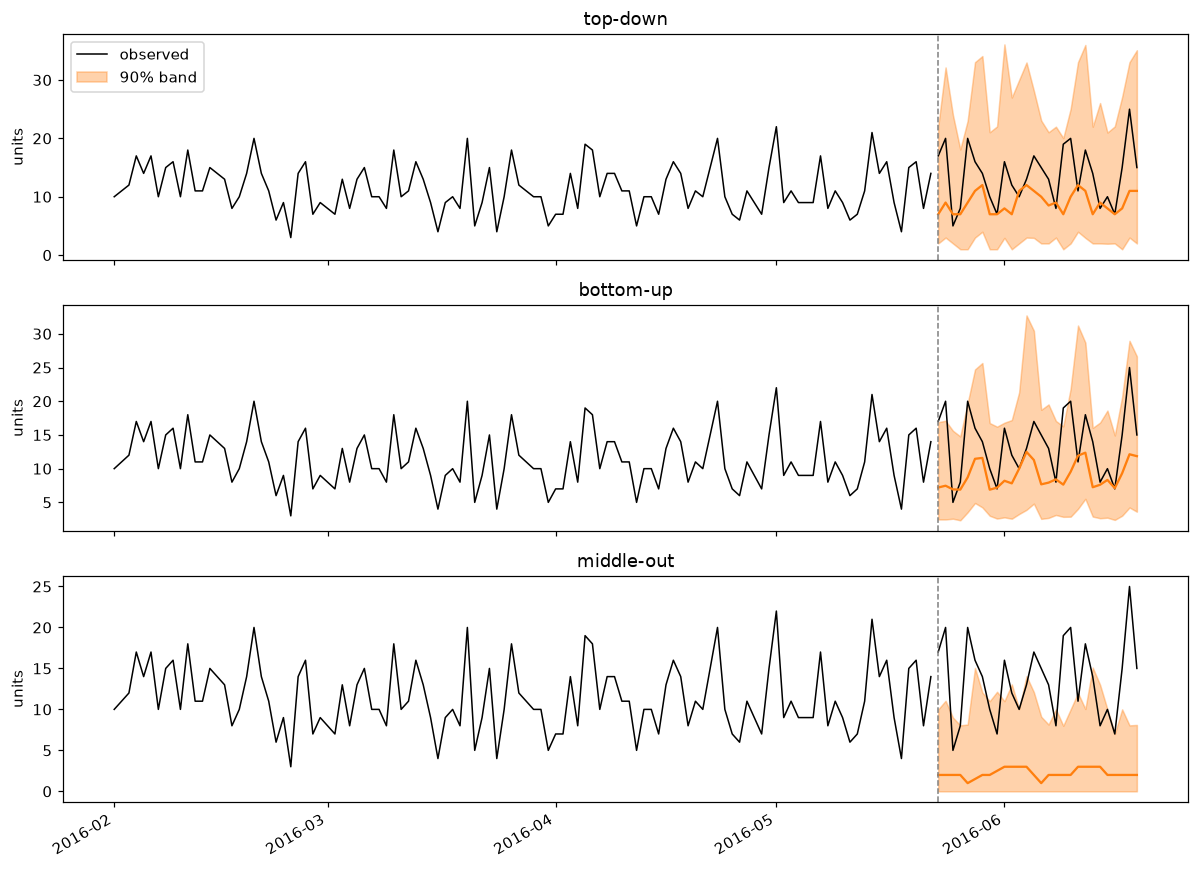

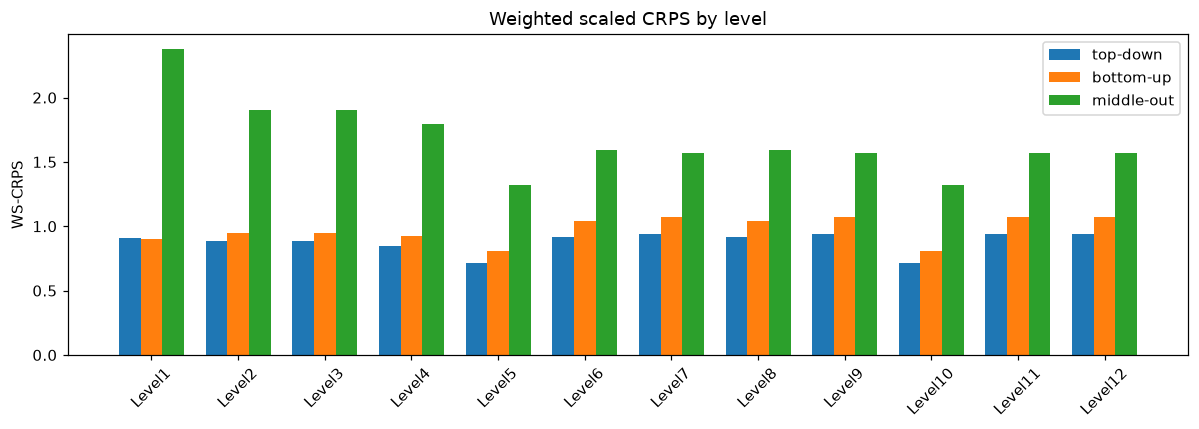

In [16]:
summary = pd.DataFrame(
    [
        {
            "model": name,
            "ws_crps": mean_level_score(scores),
            "wspl": wspl,
            "fit_seconds": elapsed,
        }
        for name, (scores, wspl, elapsed, _) in results.items()
    ]
)
print(summary.to_string(index=False))

history = panel_sales[:ORIGIN].sum(-1)
future_time = cov_top[TIME_DIM].values[ORIGIN:end]
hist_time = cov_top[TIME_DIM].values[max(0, ORIGIN - 16 * 7) : ORIGIN]
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, (name, (_, _, _, draws)) in zip(axes, results.items(), strict=True):
    total = np.asarray(draws).sum(-1)
    low, mid, high = np.quantile(total, [0.05, 0.5, 0.95], axis=0)
    ax.plot(hist_time, history[-len(hist_time) :], color="black", lw=1, label="observed")
    ax.plot(future_time, panel_sales[ORIGIN:end].sum(-1), color="black", lw=1)
    ax.fill_between(future_time, low, high, color="C1", alpha=0.35, label="90% band")
    ax.plot(future_time, mid, color="C1", lw=1.5)
    ax.axvline(future_time[0], color="gray", ls="--", lw=1)
    ax.set(title=name, ylabel="units")
axes[0].legend(loc="upper left")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(LEVELS))
width = 0.25
for k, (name, payload) in enumerate(results.items()):
    scores = payload[0]
    ax.bar(x + (k - 1) * width, [scores[level] for level in LEVELS], width, label=name)
ax.set_xticks(x, list(LEVELS), rotation=45)
ax.set(title="Weighted scaled CRPS by level", ylabel="WS-CRPS")
ax.legend()
fig.tight_layout()
plt.show()

## References

- Pyro team, [Pyro M5 starter kit](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit).
- Upstream notebook:
  <https://juanitorduz.github.io/numpyro_forecast/docs/examples/m5_forecasting.html>.
- Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*,
  [hierarchical forecasting](https://otexts.com/fpp3/hierarchical.html).
- M5 competition:
  <https://www.kaggle.com/c/m5-forecasting-uncertainty/overview>.
